# AuraFitness Calorie Estimator Testing

This notebook tests the MVP calorie burned estimator.

Important:

- This is not ML training.
- MET values are used for rule-based estimation.
- Manual cases are controlled function tests only.
- No fake training dataset is used.

Formula:

`estimated_calories = MET x body_weight_kg x duration_hours`

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from utils.calorie_estimator import CalorieEstimateRequest, estimate_calories_burned, load_met_values

REPORTS_DIR = AI_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai


## Load MET config

This cell loads the reviewed MET values from `ai/config/met_values.json`.

In [2]:
met_config = load_met_values()

print("Source:", met_config["metadata"]["source"])
print("Formula:", met_config["metadata"]["formula"])
print("Activity count:", len(met_config["activities"]))

met_rows = []

for key, value in met_config["activities"].items():
    met_rows.append({
        "activity_key": key,
        "met": value["met"],
        "label": value["label"],
        "source_code": value["source_code"],
    })

met_df = pd.DataFrame(met_rows)
display(met_df)

Source: 2024 Adult Compendium of Physical Activities
Formula: estimated_calories = MET * body_weight_kg * duration_hours
Activity count: 16


,activity_key,met,label,source_code
0,strength_general,3.5,"Resistance training, multiple exercises, 8-15 ...",02054
1,strength_compound,5.0,"Resistance training, squats, deadlift, slow or...",02052
2,strength_vigorous,6.0,"Resistance weight lifting, vigorous effort",02050
3,bodyweight_general,3.0,"Body weight resistance exercises, general",02056
4,bodyweight_high,6.5,"Body weight resistance exercises, high intensity",02057
5,circuit_light,3.5,"Circuit training, light effort",02034
6,circuit_moderate,5.0,"Circuit training, moderate effort",02035
7,circuit_vigorous,7.5,Circuit training with kettlebells/aerobic move...,02040
8,elliptical_moderate,5.0,"Elliptical trainer, moderate effort",02048
9,elliptical_vigorous,9.0,"Elliptical trainer, vigorous effort",02049


## Controlled estimator test cases

These cases test realistic gym/cardio calorie estimation scenarios.

They are not training data.

In [3]:
test_cases = [
    (
        "Strength general 60 minutes",
        CalorieEstimateRequest(
            body_weight_kg=95,
            duration_minutes=60,
            exercise_name="Dumbbell Bench Press",
            exercise_type="strength",
            intensity="moderate",
            equipment="dumbbell",
            activity_key="strength_general",
        ),
    ),
    (
        "Compound strength 45 minutes",
        CalorieEstimateRequest(
            body_weight_kg=95,
            duration_minutes=45,
            exercise_name="Barbell Squat",
            exercise_type="strength",
            intensity="moderate",
            equipment="barbell",
        ),
    ),
    (
        "Bodyweight high intensity 20 minutes",
        CalorieEstimateRequest(
            body_weight_kg=95,
            duration_minutes=20,
            exercise_name="Jump Squat Circuit",
            exercise_type="strength",
            intensity="vigorous",
            equipment="bodyweight",
        ),
    ),
    (
        "Rope skipping 10 minutes",
        CalorieEstimateRequest(
            body_weight_kg=95,
            duration_minutes=10,
            exercise_name="Rope Skipping",
            exercise_type="cardio",
            intensity="vigorous",
            equipment="bodyweight",
        ),
    ),
    (
        "Invalid body weight",
        CalorieEstimateRequest(
            body_weight_kg=-95,
            duration_minutes=30,
            exercise_name="Treadmill Walk",
            exercise_type="cardio",
            intensity="moderate",
        ),
    ),
]

## Run calorie estimates

This cell runs the rule-based calorie estimator and stores the outputs.

In [4]:
rows = []

for title, request in test_cases:
    result = estimate_calories_burned(request)

    rows.append({
        "test_case": title,
        "body_weight_kg": request.body_weight_kg,
        "duration_minutes": request.duration_minutes,
        "exercise_name": request.exercise_name,
        "exercise_type": request.exercise_type,
        "intensity": request.intensity,
        "equipment": request.equipment,
        **asdict(result),
    })

results_df = pd.DataFrame(rows)
display(results_df)

,test_case,body_weight_kg,duration_minutes,exercise_name,exercise_type,intensity,equipment,estimated_calories,met_value,activity_key,activity_label,duration_hours,confidence,formula,reason_codes,warning
0,Strength general 60 minutes,95,60,Dumbbell Bench Press,strength,moderate,dumbbell,332.5,3.5,strength_general,"Resistance training, multiple exercises, 8-15 ...",1.00,0.90,calories = MET * body_weight_kg * duration_hours,[activity_key_matched_directly],NaN
1,Compound strength 45 minutes,95,45,Barbell Squat,strength,moderate,barbell,356.2,5.0,strength_compound,"Resistance training, squats, deadlift, slow or...",0.75,0.82,calories = MET * body_weight_kg * duration_hours,[matched_strength_compound],NaN
2,Bodyweight high intensity 20 minutes,95,20,Jump Squat Circuit,strength,vigorous,bodyweight,205.8,6.5,bodyweight_high,"Body weight resistance exercises, high intensity",0.33,0.82,calories = MET * body_weight_kg * duration_hours,[matched_bodyweight_high],NaN
3,Rope skipping 10 minutes,95,10,Rope Skipping,cardio,vigorous,bodyweight,174.2,11.0,rope_skipping,"Rope skipping exercise, general",0.17,0.82,calories = MET * body_weight_kg * duration_hours,[matched_rope_skipping],NaN
4,Invalid body weight,-95,30,Treadmill Walk,cardio,moderate,NaN,0.0,0.0,invalid_input,Invalid input,0.00,0.00,calories = MET * body_weight_kg * duration_hours,[body_weight_not_positive],Invalid or unusual input values. Review body w...


## Chart estimated calories

This chart shows estimated calories for each controlled test case.

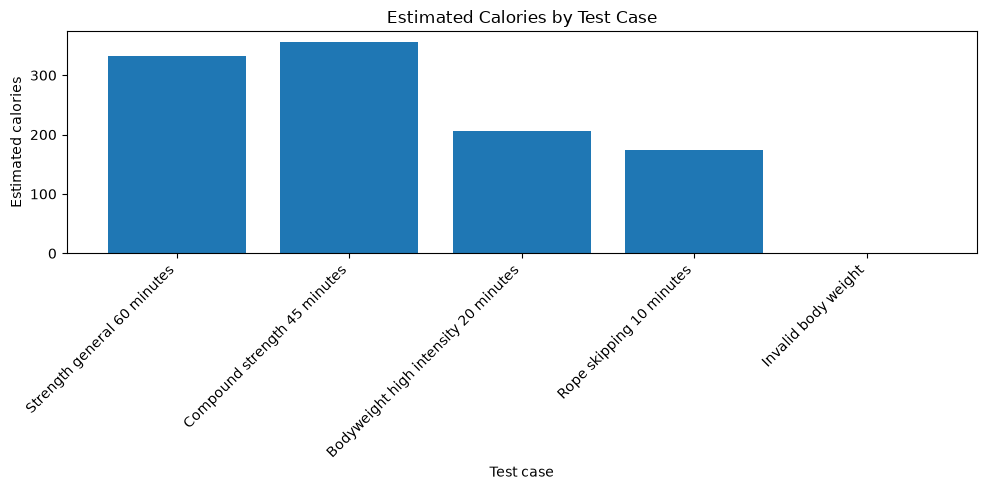

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\calorie_estimator_estimated_calories.png


In [5]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["estimated_calories"])
plt.title("Estimated Calories by Test Case")
plt.xlabel("Test case")
plt.ylabel("Estimated calories")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "calorie_estimator_estimated_calories.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart MET values used

This chart shows which MET values were selected by the estimator.

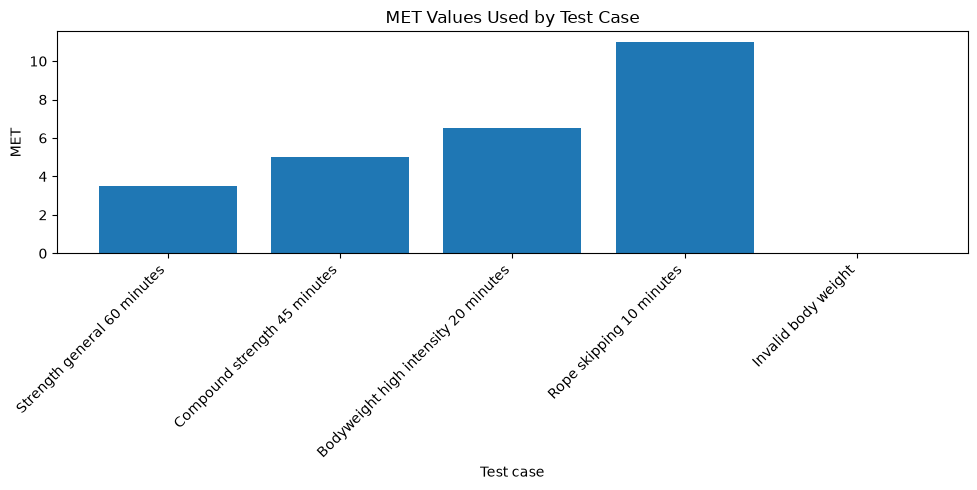

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\calorie_estimator_met_values.png


In [6]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["met_value"])
plt.title("MET Values Used by Test Case")
plt.xlabel("Test case")
plt.ylabel("MET")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "calorie_estimator_met_values.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart confidence values

This chart shows confidence for each estimation.

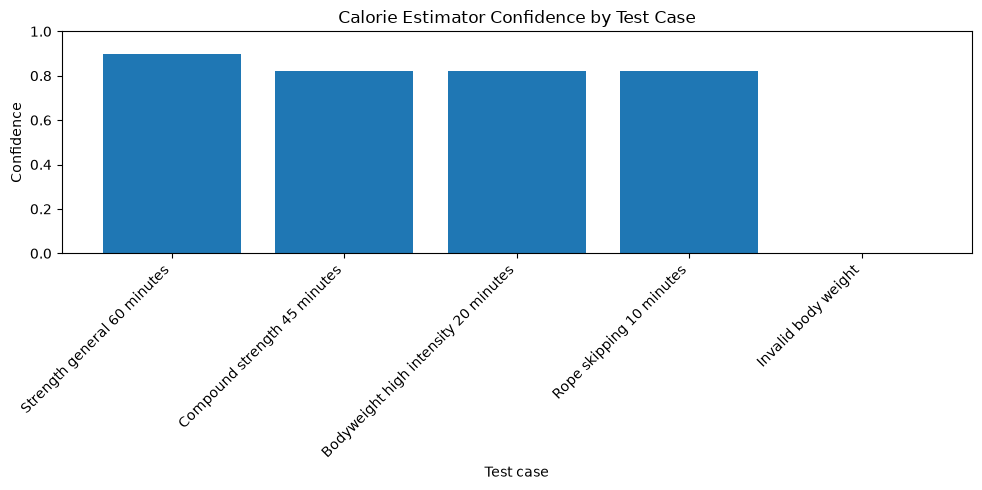

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\calorie_estimator_confidence.png


In [7]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["confidence"])
plt.title("Calorie Estimator Confidence by Test Case")
plt.xlabel("Test case")
plt.ylabel("Confidence")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "calorie_estimator_confidence.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Save calorie estimator test results

This saves the estimator results for documentation.

In [8]:
output_path = REPORTS_DIR / "calorie_estimator_test_results.csv"
results_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\calorie_estimator_test_results.csv


## Formula validation

This checks a known direct activity-key case:

95 kg x 1 hour x 3.5 MET = 332.5 kcal

In [9]:
formula_check = results_df[results_df["test_case"] == "Strength general 60 minutes"].iloc[0]

if formula_check["estimated_calories"] != 332.5:
    raise ValueError("Formula validation failed.")

print("Formula validation passed.")

Formula validation passed.


## Product mapping review

The estimator prioritizes bodyweight movement mapping before generic circuit mapping.

Reason:

If a workout is logged as bodyweight equipment and contains bodyweight movement keywords such as jump squat, push-up, pull-up, plank, or burpee, it should use the bodyweight MET mapping.

If the app wants circuit training specifically, it can pass an explicit `activity_key`, such as `circuit_vigorous`.

In [10]:
bodyweight_row = results_df[results_df["test_case"] == "Bodyweight high intensity 20 minutes"].iloc[0]

if bodyweight_row["activity_key"] != "bodyweight_high":
    raise ValueError("Expected bodyweight_high after mapping priority update.")

if bodyweight_row["estimated_calories"] != 205.8:
    raise ValueError("Expected 205.8 kcal for bodyweight_high mapping.")

print("Bodyweight mapping priority check passed.")

Bodyweight mapping priority check passed.
